In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Loan_default.csv')

print(df.shape)
print(df.head())


(255347, 18)
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      

In [4]:
print(df['Default'].value_counts(normalize=True))
print()
print(df.isnull().sum())

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


class imbalance - 88% non-default, 12% default. Need to handle this later when modeling
no missing values - unusually clean dataset, no imputation needed

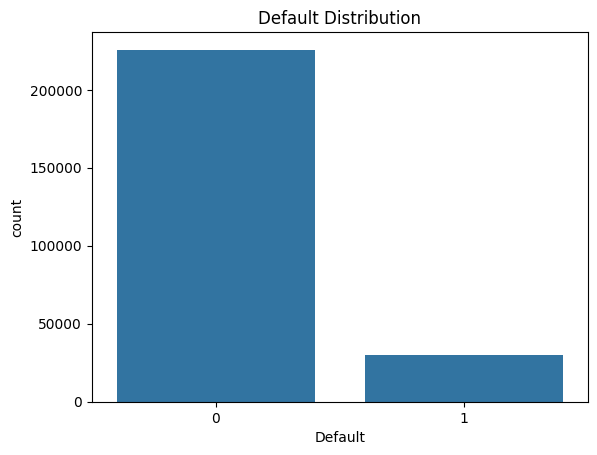

In [8]:
#class distribution
sns.countplot(x='Default', data=df)
plt.title('Default Distribution')
plt.xticks([0, 1]), ['No Default', 'Default']
plt.show()

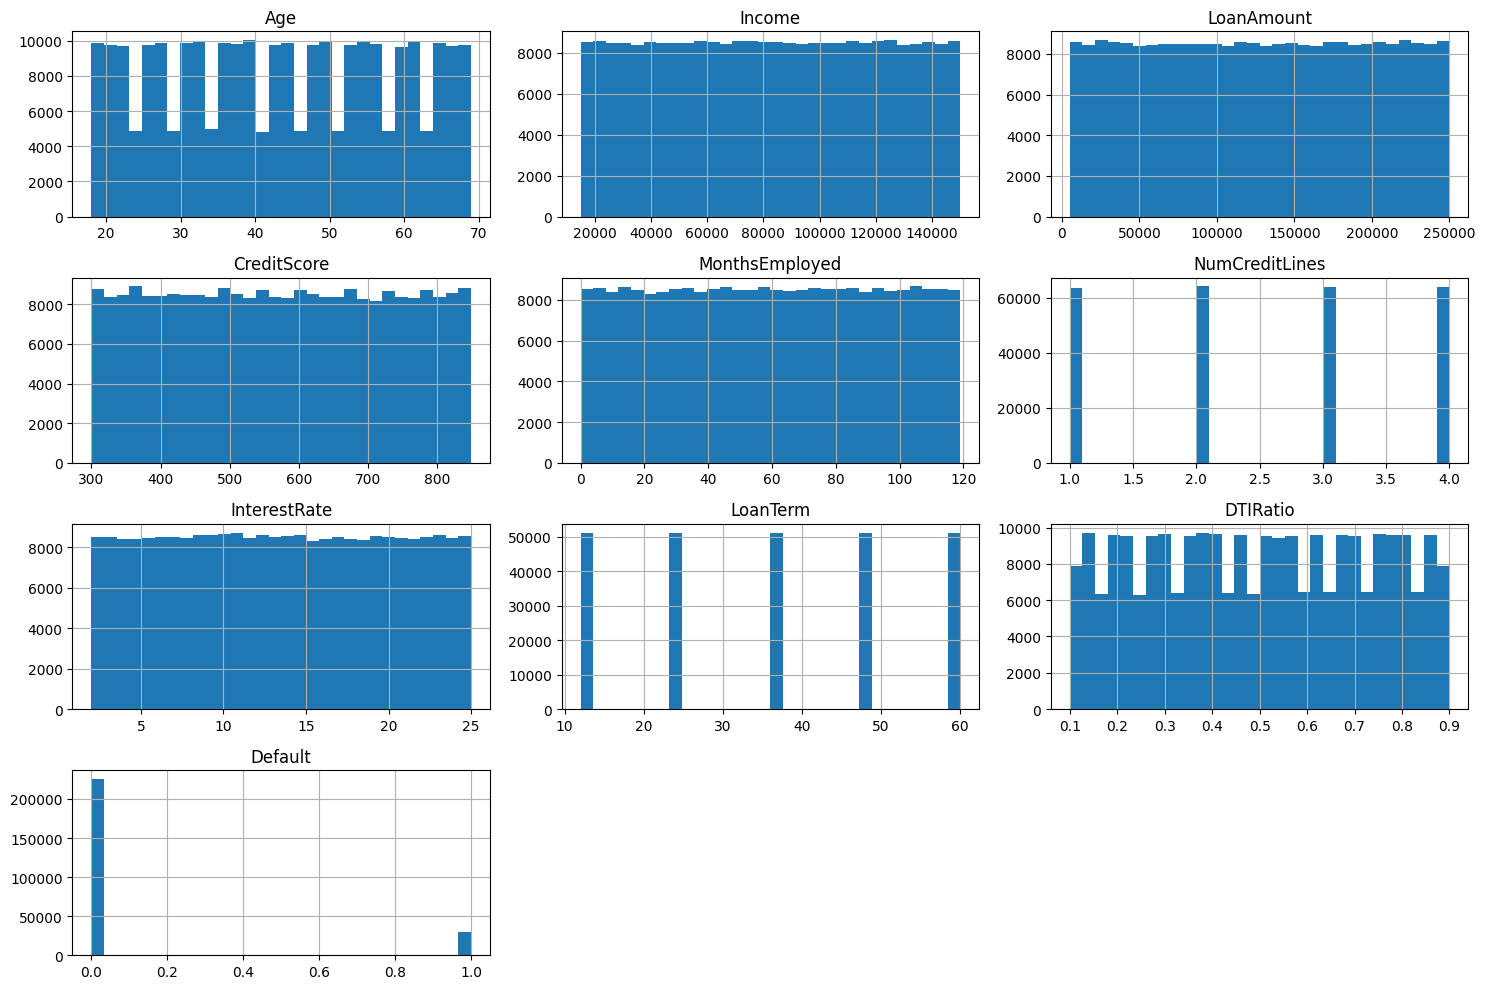

In [11]:
#distribution of numerical features
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Most features show uniform distribution, suggesting its a synthetic dataset. Rea-world loan data typically shows more skewed distributions

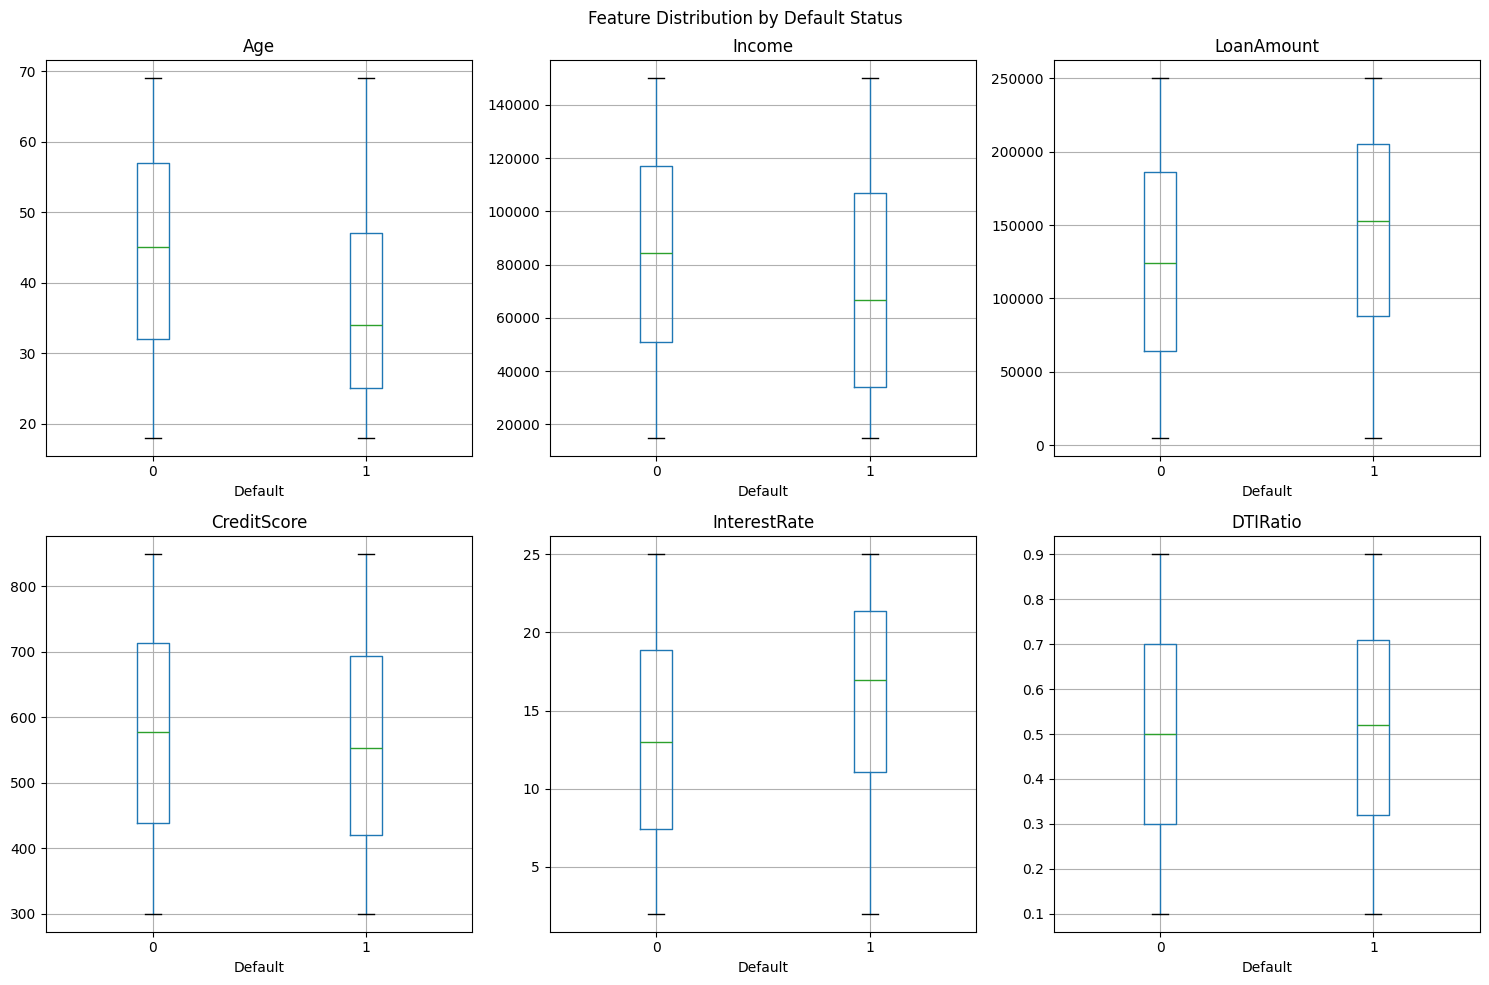

In [17]:
#compare numerical features by deafault status
fig, axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.flatten()

num_cols = ['Age','Income','LoanAmount','CreditScore','InterestRate','DTIRatio']

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Default', ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Feature Distribution by Default Status')
plt.tight_layout()
plt.show()


Clear differences between defaulters vs non-defaulters:

Age — defaulters (1) are noticeably younger, median around 34 vs 45 for non-defaulters. Age is a strong signal
Income — defaulters have lower income, median around 63k vs 83k. Makes sense
CreditScore — defaulters have slightly lower credit scores. Expected but the difference is smaller than you'd think
InterestRate — defaulters have higher interest rates, median around 17% vs 13%. This is probably the strongest signal

Not much difference:

LoanAmount — pretty similar boxes, not a strong predictor
DTIRatio — almost identical, surprisingly weak signal

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../data/Loan_default.csv')

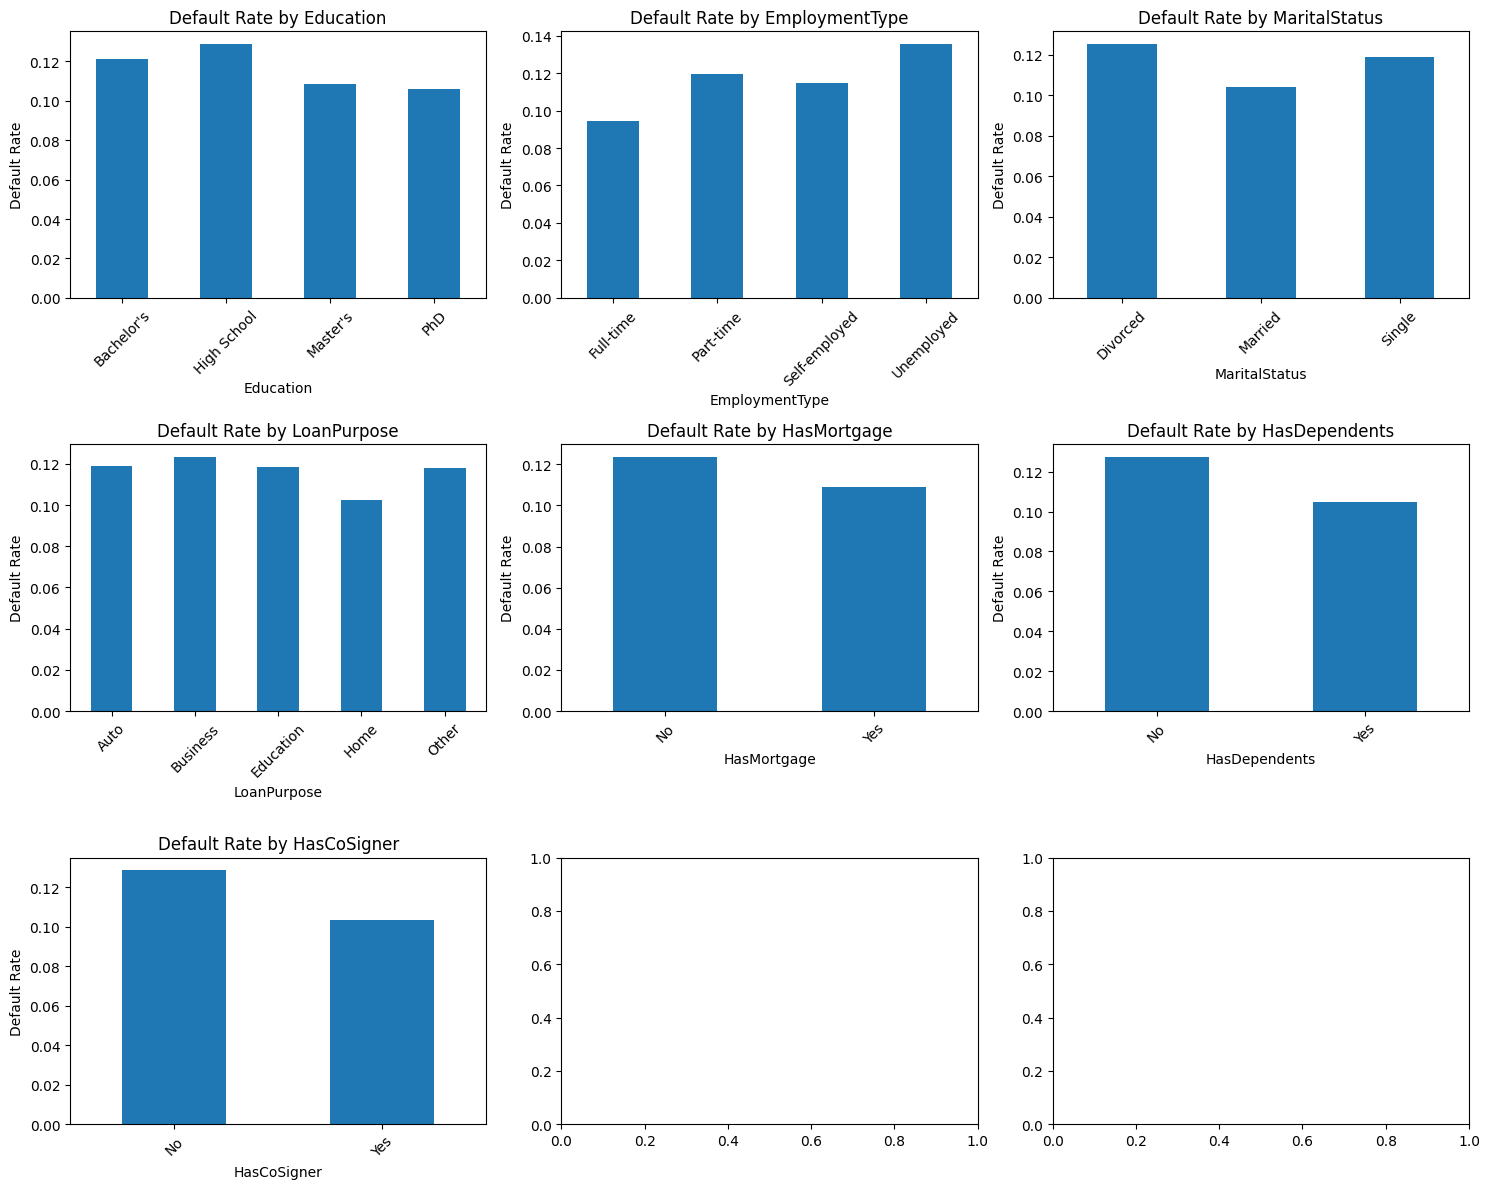

In [6]:
cat_cols = ['Education','EmploymentType','MaritalStatus','LoanPurpose','HasMortgage','HasDependents','HasCoSigner']

fig, axes = plt.subplots(3,3,figsize=(15,12))
axes=axes.flatten()

for i, col in enumerate(cat_cols):
    df.groupby(col)['Default'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Meaningful signals:

EmploymentType — Unemployed has the highest default rate (~13.5%), Full-time the lowest (~9.5%). Makes sense, strongest categorical signal
HasCoSigner — No cosigner = higher default rate. Having a cosigner reduces risk, logical
HasDependents — No dependents = higher default rate, slightly surprising
HasMortgage — No mortgage = slightly higher default. Mortgage holders may be more financially responsible

Weak signals:

Education — barely any difference across all levels, almost useless as a feature
LoanPurpose — very similar across categories, Home loans slightly lower
MaritalStatus — minimal difference